In [1]:
import os
import sys
import subprocess
import datetime
from pathlib import Path

# Setup paths
if os.getcwd() == '/home/dcor/niskhizov':
    os.chdir('/home/dcor/niskhizov/PhysicalAdverserialProj/')
    on_remote = True
else:
    on_remote = False

PROJECT_ROOT = Path(os.getcwd())
ABLATION_DIR = PROJECT_ROOT / 'ablation_study'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'ablation'

print(f"Project root: {PROJECT_ROOT}")
print(f"Ablation scripts: {ABLATION_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Project root: /home/dcor/niskhizov/PhysicalAdverserialProj
Ablation scripts: /home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study
Results directory: /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation


## Configuration

In [2]:
# Experiment configuration
EXPERIMENTS = [
    # "latent_4x4",
    # "latent_8x8",
    "latent_16x16",
    "latent_32x32",
    "latent_16x16_with_rejuv",
]

# Training parameters
NUM_EPOCHS = 30
BATCH_SIZE = 10
GPU_ID = 0  # Set to None for auto-select
USE_COMET = True  # Set to False to disable Comet ML logging

# Create timestamp for this run
RUN_TIMESTAMP = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M_%S")
RUN_DIR = RESULTS_DIR / f"run_{RUN_TIMESTAMP}"

print(f"Run timestamp: {RUN_TIMESTAMP}")
print(f"Experiments to run: {EXPERIMENTS}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"GPU: {GPU_ID if GPU_ID is not None else 'auto'}")
print(f"Comet ML: {'enabled' if USE_COMET else 'disabled'}")

Run timestamp: 2026-01-17_22_53_08
Experiments to run: ['latent_16x16', 'latent_32x32', 'latent_16x16_with_rejuv']
Epochs: 30
Batch size: 10
GPU: 0
Comet ML: enabled


## Run All Experiments

In [3]:
import torch

# Check GPU availability
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"         Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")

CUDA available: True
GPU count: 1
  GPU 0: Tesla V100-SXM2-32GB
         Memory: 31.7 GB


In [4]:
def run_experiment(exp_name, epochs, batch_size, gpu_id, output_dir, use_comet=True):
    """Run a single experiment using the ablation script."""
    script_path = ABLATION_DIR / "run_ablation_experiment.py"
    
    cmd = [
        sys.executable,
        str(script_path),
        "--experiment", exp_name,
        "--epochs", str(epochs),
        "--batch-size", str(batch_size),
        "--output-dir", str(output_dir),
    ]
    
    if gpu_id is not None:
        cmd.extend(["--gpu", str(gpu_id)])
    
    if not use_comet:
        cmd.append("--no-comet")
    
    print(f"\n{'='*60}")
    print(f"🚀 Running: {exp_name}")
    print(f"{'='*60}")
    print(f"Command: {' '.join(cmd)}\n")
    
    # Run the experiment
    result = subprocess.run(
        cmd,
        cwd=str(PROJECT_ROOT),
        capture_output=False,  # Show output in real-time
    )
    
    return result.returncode == 0

print("Experiment runner ready.")

Experiment runner ready.


In [ ]:
# Run all experiments sequentially
print("🔬 STARTING ABLATION STUDY")
print(f"Running {len(EXPERIMENTS)} experiments...\n")

results = {}
start_time = datetime.datetime.now()

for i, exp_name in enumerate(EXPERIMENTS, 1):
    print(f"\n[{i}/{len(EXPERIMENTS)}] {exp_name}")
    
    exp_start = datetime.datetime.now()
    success = run_experiment(
        exp_name=exp_name,
        epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        gpu_id=GPU_ID,
        output_dir=RUN_DIR,
        use_comet=USE_COMET
    )
    exp_duration = datetime.datetime.now() - exp_start
    
    results[exp_name] = {
        "success": success,
        "duration": str(exp_duration)
    }
    
    status = "✅" if success else "❌"
    print(f"{status} {exp_name} completed in {exp_duration}")
    
    # Clear GPU memory between experiments
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

total_duration = datetime.datetime.now() - start_time
print(f"\n{'='*60}")
print(f"🎉 All experiments complete!")
print(f"Total duration: {total_duration}")
print(f"{'='*60}")

🔬 STARTING ABLATION STUDY
Running 3 experiments...


[1/3] latent_16x16

🚀 Running: latent_16x16
Command: /home/dcor/niskhizov/anaconda3/bin/python /home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study/run_ablation_experiment.py --experiment latent_16x16 --epochs 30 --batch-size 10 --output-dir /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_53_08 --gpu 0



Using cache found in /home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
INFO:dinov2:using MLP layer as FFN


🚀 ABLATION STUDY EXPERIMENT RUNNER
Experiments to run: ['latent_16x16']
Epochs per experiment: 30
Batch size: 10
Output directory: /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_53_08
GPU: 0


############################################################
# Running: latent_16x16
############################################################

Using device: cuda:0
Setting up experiment: latent_16x16
Loading classifier ensemble...
Loading ensemble models...
✓ All models loaded successfully!
  - Inception V3
  - ResNet18
  - VGG16
  - ViT-B/16
  - DINOv2

✓ Ensemble classifier ready!
  Main function: predict_raw(image)
  Alternatives: predict_raw_weighted(image, weights_dict)
               predict_raw_per_model(image)
               ensemble_predict(image)
Classifier: ensamble_classifier
Original classes: tensor([636, 414, 748], device='cuda:0')
Loading Stable Diffusion VAE...


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.45it/s]


Loading photometric calibration...
Loaded calibration: 118x173
Loading captured frames...
Loading frames from: ./captures_frames_multiview/captures_frames_multiview_153
Loaded 439 frames


...

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : ablation_latent_16x16_2026-01-17_22_54
COMET INFO:     url                   : https://www.comet.com/dannynis/physicaladvproj-ablation/4410bf61eb7847ed9b3ac694e62dc367
COMET INFO:   Others:
COMET INFO:     Name : ablation_latent_16x16_2026-01-17_22_54
COMET INFO:   Parameters:
COMET INFO:     batch_size  : 10
COMET INFO:     dino        : 0.0
COMET INFO:     inception   : 0.25
COMET INFO:     latent_size : 16
COMET INFO:     num_epochs  : 30
COMET INFO:     rejuvenate  : False
COMET INFO:     resnet      : 0.25
COMET INFO:     vgg         : 0.25
COMET INFO:     vit         : 0.25
COMET INFO:   Uploads:
COMET INFO:     conda-environment-definition : 1

✅ latent_16x16 completed in 0:01:07.307579

[2/3] latent_32x32

🚀 Running: latent_32x32
Command: /home/dcor/niskhizov/anaconda3/bin/python /home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study/run_ablation_experiment.py --experiment latent_32x32 --epochs 30 --batch-size 10 --output-dir /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_53_08 --gpu 0



Using cache found in /home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
INFO:dinov2:using MLP layer as FFN


🚀 ABLATION STUDY EXPERIMENT RUNNER
Experiments to run: ['latent_32x32']
Epochs per experiment: 30
Batch size: 10
Output directory: /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_53_08
GPU: 0


############################################################
# Running: latent_32x32
############################################################

Using device: cuda:0
Setting up experiment: latent_32x32
Loading classifier ensemble...
Loading ensemble models...
✓ All models loaded successfully!
  - Inception V3
  - ResNet18
  - VGG16
  - ViT-B/16
  - DINOv2

✓ Ensemble classifier ready!
  Main function: predict_raw(image)
  Alternatives: predict_raw_weighted(image, weights_dict)
               predict_raw_per_model(image)
               ensemble_predict(image)
Classifier: ensamble_classifier
Original classes: tensor([636, 414, 748], device='cuda:0')
Loading Stable Diffusion VAE...


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.26it/s]


In [ ]:
# Run remaining experiments with reduced batch size to avoid OOM
import datetime
from pathlib import Path

print("🔬 CONTINUING ABLATION STUDY - Running OOM experiments with smaller batch size")

# Use existing run directory
RESULTS_DIR = PROJECT_ROOT / 'results' / 'ablation'
RUN_DIR = RESULTS_DIR / "run_2026-01-17_22_16_13"
print(f"Using existing run directory: {RUN_DIR}")

# These experiments failed due to OOM, need smaller batch size
REMAINING_EXPERIMENTS = ["latent_16x16", "latent_32x32", "latent_16x16_with_rejuv"]
SMALL_BATCH_SIZE = 5  # Reduced from 10
NUM_EPOCHS = 30
GPU_ID = 0
USE_COMET = True

results_remaining = {}
start_time = datetime.datetime.now()

for i, exp_name in enumerate(REMAINING_EXPERIMENTS, 1):
    print(f"\n[{i}/{len(REMAINING_EXPERIMENTS)}] {exp_name}")
    
    exp_start = datetime.datetime.now()
    success = run_experiment(
        exp_name=exp_name,
        epochs=NUM_EPOCHS,
        batch_size=SMALL_BATCH_SIZE,  # Use smaller batch size
        gpu_id=GPU_ID,
        output_dir=RUN_DIR,
        use_comet=USE_COMET
    )
    exp_duration = datetime.datetime.now() - exp_start
    
    results_remaining[exp_name] = {
        "success": success,
        "duration": str(exp_duration)
    }
    
    status = "✅" if success else "❌"
    print(f"{status} {exp_name} completed in {exp_duration}")
    
    # Clear GPU memory between experiments
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

total_duration = datetime.datetime.now() - start_time
print(f"\n{'='*60}")
print(f"🎉 Remaining experiments complete!")
print(f"Total duration: {total_duration}")
print(f"{'='*60}")

🔬 CONTINUING ABLATION STUDY - Running OOM experiments with smaller batch size
Using existing run directory: /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_16_13

[1/3] latent_16x16

🚀 Running: latent_16x16
Command: /home/dcor/niskhizov/anaconda3/bin/python /home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study/run_ablation_experiment.py --experiment latent_16x16 --epochs 30 --batch-size 5 --output-dir /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_16_13 --gpu 0



Using cache found in /home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/dcor/niskhizov/cache/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
INFO:dinov2:using MLP layer as FFN


Traceback (most recent call last):
  File "/home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study/run_ablation_experiment.py", line 935, in <module>
    main()
  File "/home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study/run_ablation_experiment.py", line 891, in main
    experiment.setup()
  File "/home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study/run_ablation_experiment.py", line 187, in setup
    self._load_vae()
  File "/home/dcor/niskhizov/PhysicalAdverserialProj/ablation_study/run_ablation_experiment.py", line 219, in _load_vae
    from diffusers import StableDiffusionPipeline
  File "<frozen importlib._bootstrap>", line 1412, in _handle_fromlist
  File "/home/dcor/niskhizov/anaconda3/lib/python3.12/site-packages/diffusers/utils/import_utils.py", line 844, in __getattr__
    value = getattr(module, name)
            ^^^^^^^^^^^^^^^^^^^^^
  File "/home/dcor/niskhizov/anaconda3/lib/python3.12/site-packages/diffusers/utils/import_utils.py", line 844, in __getattr

🚀 ABLATION STUDY EXPERIMENT RUNNER
Experiments to run: ['latent_16x16']
Epochs per experiment: 30
Batch size: 5
Output directory: /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_16_13
GPU: 0


############################################################
# Running: latent_16x16
############################################################

Using device: cuda:0
Setting up experiment: latent_16x16
Loading classifier ensemble...
Loading ensemble models...
✓ All models loaded successfully!
  - Inception V3
  - ResNet18
  - VGG16
  - ViT-B/16
  - DINOv2

✓ Ensemble classifier ready!
  Main function: predict_raw(image)
  Alternatives: predict_raw_weighted(image, weights_dict)
               predict_raw_per_model(image)
               ensemble_predict(image)
Classifier: ensamble_classifier
Original classes: tensor([636, 414, 748], device='cuda:0')
Loading Stable Diffusion VAE...


KeyboardInterrupt: 

In [ ]:
# Summary of experiment runs
print("\n📊 EXPERIMENT RUN SUMMARY")
print("="*50)
for exp_name, result in results.items():
    status = "✅ Success" if result["success"] else "❌ Failed"
    print(f"{exp_name}: {status} ({result['duration']})")

successful = sum(1 for r in results.values() if r["success"])
print(f"\nTotal: {successful}/{len(results)} successful")


📊 EXPERIMENT RUN SUMMARY
latent_4x4: ✅ Success (0:09:20.985093)

Total: 1/1 successful


---
## Results Analysis

Load and analyze the results from all completed experiments.

In [ ]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

%matplotlib inline

print("Analysis libraries loaded.")

Analysis libraries loaded.


In [ ]:
def find_experiment_dirs(base_dir):
    """Find all experiment directories."""
    base_dir = Path(base_dir)
    exp_dirs = {}
    
    for d in base_dir.iterdir():
        if d.is_dir() and (d / "metadata.pkl").exists():
            # Extract experiment name
            exp_name = d.name.split('_2')[0]  # Split before timestamp
            exp_dirs[exp_name] = d
    
    return exp_dirs

def load_results(exp_dir):
    """Load results from an experiment directory."""
    exp_dir = Path(exp_dir)
    metadata_path = exp_dir / "metadata.pkl"
    
    if metadata_path.exists():
        with open(metadata_path, 'rb') as f:
            return pickle.load(f)
    return None

# Find experiment directories
exp_dirs = find_experiment_dirs(RUN_DIR)

if not exp_dirs:
    # Try finding in the general results directory
    exp_dirs = find_experiment_dirs(RESULTS_DIR)

print(f"Found {len(exp_dirs)} experiment directories:")
for name, path in sorted(exp_dirs.items()):
    print(f"  - {name}: {path.name}")

Found 1 experiment directories:
  - latent_4x4: latent_4x4_2026-01-17_22_16_33


In [ ]:
# Load all results
all_results = {}

for exp_name, exp_dir in sorted(exp_dirs.items()):
    results = load_results(exp_dir)
    if results:
        all_results[exp_name] = results
        print(f"✅ Loaded: {exp_name}")
        print(f"   Best success rate: {results.get('best_success_rate', 0):.1%}")
        print(f"   Final aug rate: {results.get('final_aug_rate', 0):.1%}")
        print(f"   Epochs run: {results.get('total_epochs_run', 'N/A')}")
    else:
        print(f"❌ Failed to load: {exp_name}")

print(f"\nTotal loaded: {len(all_results)} experiments")

✅ Loaded: latent_4x4
   Best success rate: 69.0%
   Final aug rate: 96.7%
   Epochs run: 13

Total loaded: 1 experiments


### Success Rate Convergence

/tmp/ipykernel_1543272/3832785253.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=10)


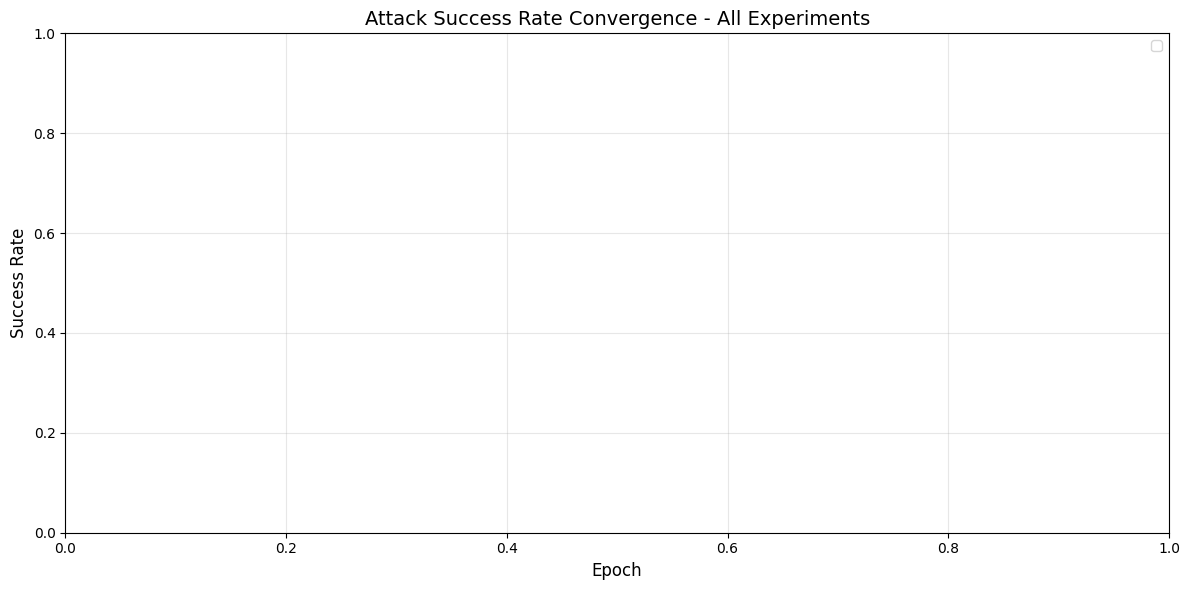

In [ ]:
# Plot success rate convergence for all experiments
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'latent_4x4': '#e74c3c',
    'latent_8x8': '#f39c12',
    'latent_16x16': '#2ecc71',
    'latent_32x32': '#3498db',
    'latent_16x16_with_rejuv': '#9b59b6',
}

for exp_name, results in sorted(all_results.items()):
    if 'success_rate_history' in results:
        success_rates = results['success_rate_history']
        color = colors.get(exp_name, 'gray')
        ax.plot(success_rates, label=exp_name, linewidth=2.5, color=color)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Attack Success Rate Convergence - All Experiments', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RUN_DIR / 'convergence_all.png', dpi=150, bbox_inches='tight')
plt.show()

### Loss Convergence

In [ ]:
# Plot loss convergence
fig, ax = plt.subplots(figsize=(12, 6))

for exp_name, results in sorted(all_results.items()):
    if 'loss_history' in results:
        losses = results['loss_history']
        color = colors.get(exp_name, 'gray')
        ax.plot(losses, label=exp_name, linewidth=2, color=color)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Convergence', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_DIR / 'loss_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparison Bar Charts

In [ ]:
# Create comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

exp_names = list(all_results.keys())
bar_colors = [colors.get(name, 'gray') for name in exp_names]

# Best success rate
ax = axes[0]
best_rates = [all_results[name].get('best_success_rate', 0) for name in exp_names]
bars = ax.bar(exp_names, best_rates, color=bar_colors)
ax.set_ylabel('Best Success Rate')
ax.set_title('Best Success Rate')
ax.set_ylim(0, 1)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, rate in zip(bars, best_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{rate:.1%}', ha='center', va='bottom', fontsize=9)

# Final aug rate
ax = axes[1]
aug_rates = [all_results[name].get('final_aug_rate', 0) for name in exp_names]
bars = ax.bar(exp_names, aug_rates, color=bar_colors)
ax.set_ylabel('Final Augmented Rate')
ax.set_title('Final Augmented Success Rate')
ax.set_ylim(0, 1)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, rate in zip(bars, aug_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{rate:.1%}', ha='center', va='bottom', fontsize=9)

# Epochs to 50%
ax = axes[2]
epochs_list = []
for name in exp_names:
    e = all_results[name].get('epochs_to_50_percent')
    epochs_list.append(e if e is not None else all_results[name].get('total_epochs_run', NUM_EPOCHS))
bars = ax.bar(exp_names, epochs_list, color=bar_colors)
ax.set_ylabel('Epochs')
ax.set_title('Epochs to 50% Success')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, ep, name in zip(bars, epochs_list, exp_names):
    label = str(ep) if all_results[name].get('epochs_to_50_percent') is not None else 'N/R'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            label, ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RUN_DIR / 'comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

### Latent Size Comparison

In [ ]:
# Compare latent sizes (excluding rejuvenation experiment)
fig, ax = plt.subplots(figsize=(10, 6))

latent_experiments = {k: v for k, v in all_results.items() if 'rejuv' not in k}

for exp_name, results in sorted(latent_experiments.items()):
    if 'success_rate_history' in results:
        color = colors.get(exp_name, 'gray')
        ax.plot(results['success_rate_history'], 
               label=exp_name, linewidth=2.5, color=color)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Effect of Latent Size on Attack Success Rate', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RUN_DIR / 'latent_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Rejuvenation Comparison

In [ ]:
# Compare rejuvenation vs no rejuvenation (16x16)
fig, ax = plt.subplots(figsize=(10, 6))

rejuv_experiments = {k: v for k, v in all_results.items() if '16x16' in k}

for exp_name, results in rejuv_experiments.items():
    if 'success_rate_history' in results:
        label = "With Rejuvenation" if 'rejuv' in exp_name else "Without Rejuvenation"
        color = '#2ecc71' if 'rejuv' in exp_name else '#e74c3c'
        linestyle = '-' if 'rejuv' in exp_name else '--'
        ax.plot(results['success_rate_history'], 
               label=label, linewidth=2.5, color=color, linestyle=linestyle)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Effect of Patch Rejuvenation (16x16 Latent)', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RUN_DIR / 'rejuvenation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary Table

In [ ]:
# Create summary table
summary_data = []

for exp_name, results in sorted(all_results.items()):
    config = results.get('config', {})
    summary_data.append({
        "Experiment": exp_name,
        "Latent Size": f"{config.get('latent_size', 'N/A')}x{config.get('latent_size', 'N/A')}",
        "Rejuvenation": "Yes" if config.get('rejuvenate', False) else "No",
        "Best Success Rate": f"{results.get('best_success_rate', 0):.1%}",
        "Final Aug Rate": f"{results.get('final_aug_rate', 0):.1%}",
        "Epochs to 50%": results.get('epochs_to_50_percent') if results.get('epochs_to_50_percent') else "N/R",
        "Total Epochs": results.get('total_epochs_run', 'N/A'),
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("📊 ABLATION STUDY SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Save summary
summary_df.to_csv(RUN_DIR / 'summary.csv', index=False)
print(f"\nSummary saved to: {RUN_DIR / 'summary.csv'}")


📊 ABLATION STUDY SUMMARY
Experiment Latent Size Rejuvenation Best Success Rate Final Aug Rate  Epochs to 50%  Total Epochs
latent_4x4         4x4           No             69.0%          96.7%              5            13

Summary saved to: /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_16_13/summary.csv


### View Generated Patches

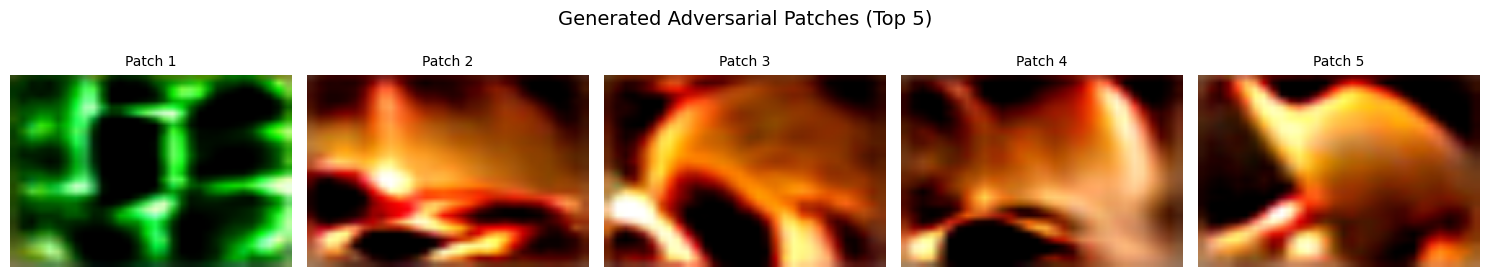

In [ ]:
# Display best patches from each experiment
import cv2
from IPython.display import display, HTML

fig, axes = plt.subplots(len(exp_dirs), 5, figsize=(15, 3*len(exp_dirs)))

if len(exp_dirs) == 1:
    axes = axes.reshape(1, -1)

for row, (exp_name, exp_dir) in enumerate(sorted(exp_dirs.items())):
    # Load first 5 patches
    for col in range(5):
        patch_path = exp_dir / f"patch_{col+1:02d}.png"
        if patch_path.exists():
            img = cv2.cvtColor(cv2.imread(str(patch_path)), cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img)
            if col == 0:
                axes[row, col].set_ylabel(exp_name, fontsize=10)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f"Patch {col+1}", fontsize=10)

plt.suptitle('Generated Adversarial Patches (Top 5)', fontsize=14)
plt.tight_layout()
plt.savefig(RUN_DIR / 'all_patches.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings

In [ ]:
# Analyze key findings
print("\n" + "="*60)
print("🔍 KEY FINDINGS")
print("="*60)

if all_results:
    # Best overall performer
    best_exp = max(all_results.items(), key=lambda x: x[1].get('best_success_rate', 0))
    print(f"\n1. BEST OVERALL PERFORMER: {best_exp[0]}")
    print(f"   Success Rate: {best_exp[1].get('best_success_rate', 0):.1%}")
    
    # Fastest to converge
    convergence_data = [(name, r.get('epochs_to_50_percent')) 
                        for name, r in all_results.items() 
                        if r.get('epochs_to_50_percent') is not None]
    if convergence_data:
        fastest = min(convergence_data, key=lambda x: x[1])
        print(f"\n2. FASTEST TO 50%: {fastest[0]}")
        print(f"   Epochs: {fastest[1]}")
    
    # Latent size effect
    latent_exps = {k: v for k, v in all_results.items() if 'rejuv' not in k}
    if len(latent_exps) > 1:
        print(f"\n3. LATENT SIZE EFFECT:")
        for name in sorted(latent_exps.keys()):
            rate = latent_exps[name].get('best_success_rate', 0)
            print(f"   {name}: {rate:.1%}")
    
    # Rejuvenation effect
    rejuv_16x16 = all_results.get('latent_16x16_with_rejuv', {})
    no_rejuv_16x16 = all_results.get('latent_16x16', {})
    if rejuv_16x16 and no_rejuv_16x16:
        print(f"\n4. REJUVENATION EFFECT (16x16):")
        print(f"   Without: {no_rejuv_16x16.get('best_success_rate', 0):.1%}")
        print(f"   With:    {rejuv_16x16.get('best_success_rate', 0):.1%}")
        diff = rejuv_16x16.get('best_success_rate', 0) - no_rejuv_16x16.get('best_success_rate', 0)
        print(f"   Difference: {diff:+.1%}")

print("\n" + "="*60)


🔍 KEY FINDINGS

1. BEST OVERALL PERFORMER: latent_4x4
   Success Rate: 69.0%

2. FASTEST TO 50%: latent_4x4
   Epochs: 5



In [ ]:
# Save all analysis results
analysis_results = {
    'all_results': all_results,
    'summary': summary_data,
    'run_timestamp': RUN_TIMESTAMP,
}

with open(RUN_DIR / 'analysis_results.pkl', 'wb') as f:
    pickle.dump(analysis_results, f)

print(f"\n✅ Analysis complete!")
print(f"Results saved to: {RUN_DIR}")
print(f"\nFiles:")
for f in sorted(RUN_DIR.glob('*.png')):
    print(f"  - {f.name}")
for f in sorted(RUN_DIR.glob('*.csv')):
    print(f"  - {f.name}")
for f in sorted(RUN_DIR.glob('*.pkl')):
    print(f"  - {f.name}")


✅ Analysis complete!
Results saved to: /home/dcor/niskhizov/PhysicalAdverserialProj/results/ablation/run_2026-01-17_22_16_13

Files:
  - all_patches.png
  - convergence_all.png
  - summary.csv
  - analysis_results.pkl
